In [1]:
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron")
import glob
import dill
import mudata
import pyranges as pr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scenicplus.utils import get_interaction_pr
from scenicplus.networks import concentrical_layout, create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape

In [2]:
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
with open('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/scplus_obj.pkl', 'rb') as f:
    scplus_obj = dill.load(f)

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/region_to_gene_adj.tsv",sep = '\t')
scplus_obj.uns['region_to_gene'] = region_to_gene.copy()

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed i

In [3]:
scplus_mdata.uns['direct_e_regulon_metadata'][scplus_mdata.uns['direct_e_regulon_metadata']['Region_signature_name'].isin(scplus_mdata['direct_region_based_AUC'].var.index)]['TF'].unique()

array(['ASCL1', 'BRCA1', 'CREB5', 'E2F7', 'ETV1', 'ETV5', 'GLIS3',
       'HOXA3', 'HOXB3', 'HOXB6', 'HOXB7', 'HOXB8', 'HOXB9', 'HOXD3',
       'KLF12', 'LHX1', 'LMX1B', 'MEIS1', 'MEIS2', 'MXI1', 'NFIA', 'NFIB',
       'NKX2-2', 'NR3C1', 'OLIG1', 'OLIG2', 'PAX3', 'PBX1', 'PBX3',
       'POU2F1', 'RAD21', 'RARB', 'RFX3', 'RFX4', 'SOX10', 'SOX11',
       'SOX2', 'SOX4', 'SOX5', 'SOX6', 'TCF12', 'TCF4', 'TFDP2', 'ZBTB20',
       'ZIC1', 'ZNF654', 'EZH2', 'FOXM1', 'HES1', 'IKZF2', 'LHX9', 'NF1',
       'NR2F1', 'PAX2', 'PAX6', 'SREBF1', 'YBX1'], dtype=object)

https://github.com/aertslab/scenicplus/discussions/511

Region: predicted target region

Gene: predicted target gene

importance_R2G: importance score of region-to-gene link (from GRNBoost)

rho_R2G: correlation coefficient of region-to-gene link

importance_x_rho: the product of the previous two columns

importance_x_abs_rho: the product of the previous two columns, but the absolute value of rho_R2G is taken

TF: TF name

is_extended: wether the motif-to-TF annotation is from direct evidence or not (i.e. orthology or similarity based)

eRegulon_name: regulon name

Gene_signature_name: gene signature name

Region_signature_name: region signature name

importance_TF2G: TF-to-gene importance score (grn boost)

regulation: wether the interaction is activating or repressive

rho_TF2G: TF-to-gene correlation coefficient

triplet_rank: Triplet rank score (see paper for detailed explanation)

In [4]:
scplus_mdata.uns['direct_e_regulon_metadata']['eRegulon_name'].value_counts()

NFIA_direct_+/+      3207
RFX3_direct_+/+      1583
SOX2_direct_+/+      1454
NFIB_direct_+/+      1431
SOX6_direct_+/+      1050
                     ... 
FOXM1_direct_+/-       15
OLIG1_direct_+/+       13
SREBF1_direct_+/-      13
ETV5_direct_+/+        12
MXI1_direct_+/+        12
Name: eRegulon_name, Length: 92, dtype: int64

In [6]:
network = scplus_mdata.uns['direct_e_regulon_metadata'].loc[scplus_mdata.uns['direct_e_regulon_metadata']['eRegulon_name'].isin(['PAX3_direct_+/+', 'TFDP2_direct_+/+', 'YBX1_direct_+/-']) ,:]
network

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
12085,chr3:47542640-47543141,SMARCC1,0.045795,0.060706,0.002780,0.002780,PAX3,False,PAX3_direct_+/+,PAX3_direct_+/+_(117g),PAX3_direct_+/+_(240r),0.692480,1,0.162595,20549
12086,chr17:73320865-73321366,CDC42EP4,0.018788,0.081033,0.001522,0.001522,PAX3,False,PAX3_direct_+/+,PAX3_direct_+/+_(117g),PAX3_direct_+/+_(240r),1.413964,1,0.155863,13403
12087,chr10:96495312-96495813,TLL2,0.128040,0.190940,0.024448,0.024448,PAX3,False,PAX3_direct_+/+,PAX3_direct_+/+_(117g),PAX3_direct_+/+_(240r),1.226596,1,0.117692,11537
12088,chr12:102865945-102866446,ASCL1,0.026381,0.098069,0.002587,0.002587,PAX3,False,PAX3_direct_+/+,PAX3_direct_+/+_(117g),PAX3_direct_+/+_(240r),2.695451,1,0.203809,7696
12089,chr3:16487688-16488189,RFTN1,0.045123,0.065851,0.002971,0.002971,PAX3,False,PAX3_direct_+/+,PAX3_direct_+/+_(117g),PAX3_direct_+/+_(240r),0.824029,1,0.067143,21110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31019,chr12:55996918-55997419,RPS26,0.084574,-0.140716,-0.011901,0.011901,YBX1,False,YBX1_direct_+/-,YBX1_direct_+/-_(91g),YBX1_direct_+/-_(120r),0.487545,1,0.137000,15888
31020,chr11:65111571-65112072,FAU,0.084316,-0.103897,-0.008760,0.008760,YBX1,False,YBX1_direct_+/-,YBX1_direct_+/-_(91g),YBX1_direct_+/-_(120r),1.321863,1,0.263868,4798
31021,chr3:12841292-12841793,RPL32,0.029443,-0.068191,-0.002008,0.002008,YBX1,False,YBX1_direct_+/-,YBX1_direct_+/-_(91g),YBX1_direct_+/-_(120r),3.909726,1,0.345723,9404
31022,chr19:49339353-49339854,RPL13A,0.085842,-0.113788,-0.009768,0.009768,YBX1,False,YBX1_direct_+/-,YBX1_direct_+/-_(91g),YBX1_direct_+/-_(120r),2.404860,1,0.365139,2129


In [7]:
network['Region'].value_counts()

chr13:99958821-99959322     3
chr17:73262251-73262752     2
chr20:37232186-37232687     2
chr13:99959557-99960058     2
chr19:35947352-35947853     2
                           ..
chr3:71070730-71071231      1
chr5:174720884-174721385    1
chr8:28589056-28589557      1
chr3:147354614-147355115    1
chr13:99895988-99896489     1
Name: Region, Length: 560, dtype: int64

In [13]:
scplus_obj.X_ACC #162500 rows × 10248 columns
scplus_obj.X_EXP #10248 rows × 36601 columns
scplus_obj.uns.keys() #dict_keys(['eRegulon_metadata', 'eRegulon_AUC', 'eRegulons'])
scplus_obj.uns['eRegulon_AUC'].keys() #dict_keys(['Gene_based', 'Region_based'])
scplus_obj.uns['eRegulon_AUC']['Gene_based'] #10248 rows × 167 columns
scplus_obj.uns['eRegulon_AUC']['Region_based'] #10248 rows × 167 columns

,ASCL1_direct_+/+_(32r),BRCA1_direct_+/+_(303r),BRCA1_direct_+/-_(276r),CREB5_direct_+/+_(25r),E2F7_direct_+/+_(554r),E2F7_direct_+/-_(273r),ETV1_direct_+/+_(48r),ETV5_direct_+/+_(12r),EZH2_direct_+/-_(56r),FOXM1_direct_+/-_(14r),...,SOX6_extended_-/-_(67r),SOX9_extended_+/+_(236r),SOX9_extended_+/-_(150r),TCF12_extended_+/+_(644r),TCF12_extended_+/-_(399r),TCF4_extended_+/+_(254r),TCF4_extended_+/-_(215r),TCF7L2_extended_+/+_(180r),TCF7L2_extended_+/-_(165r),UNCX_extended_+/-_(14r)
Cell,,,,,,,,,,,,,,,,,,,,,
CTGACCAAGCATGTTA-1-4___cisTopic,0.000000,0.032288,0.178899,0.021218,0.046352,0.185715,0.003144,0.000000,0.008303,0.000000,...,0.000874,0.012296,0.042465,0.015506,0.011154,0.007341,0.008713,0.006195,0.016334,0.000000
GGCCATCAGGGACCTC-1-6___cisTopic,0.118796,0.040696,0.112376,0.172834,0.055195,0.126996,0.214538,0.152092,0.263123,0.042954,...,0.108400,0.070186,0.150590,0.018379,0.128244,0.045579,0.085962,0.065627,0.001840,0.118198
AATCGCCCAATTAGGA-1-2___cisTopic,0.000000,0.049798,0.170148,0.052455,0.050316,0.188590,0.016149,0.000000,0.009156,0.000000,...,0.012690,0.011779,0.043709,0.012614,0.011621,0.002849,0.005761,0.009412,0.025461,0.030602
AGGACGTAGGAAACTG-1-1___cisTopic,0.000000,0.042392,0.162757,0.043185,0.053218,0.164507,0.094700,0.126964,0.105163,0.026549,...,0.082131,0.033331,0.109857,0.008481,0.053474,0.006187,0.027194,0.035916,0.013867,0.037486
CCAGGAACAATCCTAG-1-4___cisTopic,0.000000,0.030925,0.185080,0.024610,0.045338,0.190302,0.005954,0.000000,0.009963,0.000000,...,0.002041,0.012066,0.039229,0.016086,0.010233,0.006866,0.008903,0.005877,0.016454,0.005503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCCTTAGTCGCTAGCA-1-5___cisTopic,0.000000,0.077144,0.143359,0.089930,0.096033,0.155118,0.078859,0.000000,0.032765,0.000000,...,0.033745,0.039932,0.057027,0.004412,0.022377,0.001297,0.008276,0.015140,0.018077,0.071138
CCTGGATCACAAAGAC-1-5___cisTopic,0.009754,0.037581,0.171200,0.039429,0.047761,0.161206,0.070792,0.089600,0.116424,0.037495,...,0.076624,0.030382,0.116472,0.007629,0.059623,0.010066,0.034283,0.022414,0.013705,0.045248
CTGTACCTCCGTGACA-1-7___cisTopic,0.031415,0.038908,0.146324,0.104561,0.057136,0.155433,0.151556,0.119990,0.128286,0.017240,...,0.088105,0.047487,0.109644,0.011571,0.075227,0.020559,0.043504,0.042203,0.012443,0.083367


In [14]:
scplus_obj.uns['eRegulon_metadata']

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr20:37416066-37416567,NNAT,0.051961,0.255879,0.013296,0.013296,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(23g),ASCL1_direct_+/+_(32r),0.690096,1,0.157641,29695
1,chr18:49584337-49584838,RPL17,0.121065,0.091964,0.011134,0.011134,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(23g),ASCL1_direct_+/+_(32r),1.571699,1,0.191665,10127
2,chr8:60908747-60909248,CHD7,0.049249,0.389336,0.019174,0.019174,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(23g),ASCL1_direct_+/+_(32r),0.522935,1,0.216903,20779
3,chr14:77143019-77143520,ZDHHC22,0.086654,0.065118,0.005643,0.005643,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(23g),ASCL1_direct_+/+_(32r),0.757186,1,0.087142,19423
4,chr11:35919279-35919780,LDLRAD3,0.060242,0.266976,0.016083,0.016083,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(23g),ASCL1_direct_+/+_(32r),0.843478,1,0.215197,22514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51093,chr10:33178073-33178574,NRP1,0.006107,-0.065581,-0.000400,0.000400,SOX6,True,SOX6_extended_-/-,SOX6_extended_-/-_(51g),SOX6_extended_-/-_(67r),4.009629,-1,-0.169601,7699
51094,chr5:137622710-137623211,SPOCK1,0.001984,-0.161539,-0.000321,0.000321,SOX6,True,SOX6_extended_-/-,SOX6_extended_-/-_(51g),SOX6_extended_-/-_(67r),3.078430,-1,-0.088434,12468
51095,chr2:1826124-1826625,MYT1L,0.002391,-0.271854,-0.000650,0.000650,SOX6,True,SOX6_extended_-/-,SOX6_extended_-/-_(51g),SOX6_extended_-/-_(67r),5.264928,-1,-0.231318,4684
51096,chr1:151839643-151840144,CELF3,0.078196,-0.139492,-0.010908,0.010908,SOX6,True,SOX6_extended_-/-,SOX6_extended_-/-_(51g),SOX6_extended_-/-_(67r),3.504476,-1,-0.085327,1497


In [156]:
nx_tables = create_nx_tables(scplus_obj,
                    eRegulon_metadata_key = 'eRegulon_metadata',
                    subset_eRegulons = ['ZBTB20_direct', 'NR2F1_direct'],
                    subset_regions = None,
                    subset_genes = None,
                    add_differential_gene_expression = False,
                    add_differential_region_accessibility = False,
                    #differential_variable = ['ACC_Seurat_cell_type', 'ACC_VSN_cell_type'])
                    differential_variable = ['celltype'])

In [ ]:
edge_df_TF2R = nx_tables['Edge']['TF2R'][nx_tables['Edge']['TF2R']['eRegulon_name'].isin(['ZBTB20_direct_+/+', 'NR2F1_direct_+/-'])]
# edge_df_TF2R = edge_df_TF2R.sort_values(by='triplet_rank', ascending=True)
# edge_df_TF2R = edge_df_TF2R.drop_duplicates(subset=['TF', 'Region'], keep='first')
edge_df_TF2R

,TF,Region,Gene_signature_name,Region_signature_name,eRegulon_name,importance_x_abs_rho,importance_x_rho,is_extended,regulation,triplet_rank
23021,ZBTB20,chrX:9341852-9342353,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.017504,0.017504,False,1,96
22908,ZBTB20,chr11:46119642-46120143,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.004397,0.004397,False,1,140
22949,ZBTB20,chr15:45378315-45378816,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.023780,0.023780,False,1,286
22897,ZBTB20,chr15:34437564-34438065,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.028198,0.028198,False,1,330
22682,ZBTB20,chr11:28110031-28110532,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.040893,0.040893,False,1,336
...,...,...,...,...,...,...,...,...,...,...
26031,NR2F1,chr11:2539630-2540131,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.004592,-0.004592,False,1,29996
26037,NR2F1,chr11:63489788-63490289,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.000849,-0.000849,False,1,30056
26025,NR2F1,chr19:11465467-11465968,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.002207,-0.002207,False,1,30371
26019,NR2F1,chr17:81329331-81329832,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.000902,-0.000902,False,1,31331


In [237]:

region_counts = edge_df_TF2R['Region'].value_counts()
edge_df_TF2R['indegree'] = edge_df_TF2R['Region'].map(region_counts)


In [238]:
# 首先筛选指定的eRegulon，然后按indegree排序并取前150行
edge_df_TF2R = edge_df_TF2R.sort_values('indegree', ascending=False).head(150)  # 取前150行


In [239]:
edge_df_TF2R['indegree'].value_counts()

1    150
Name: indegree, dtype: int64

In [234]:
edge_df_TF2R

,TF,Region,Gene_signature_name,Region_signature_name,eRegulon_name,importance_x_abs_rho,importance_x_rho,is_extended,regulation,triplet_rank,indegree
22866,ZBTB20,chr19:13022151-13022652,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.004959,0.004959,False,1,10751,3
22867,ZBTB20,chr10:102628252-102628753,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.003647,0.003647,False,1,7870,3
22828,ZBTB20,chr10:102815303-102815804,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.002844,0.002844,False,1,11717,3
22688,ZBTB20,chr10:102815303-102815804,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.000723,0.000723,False,1,19164,3
22913,ZBTB20,chr5:139764325-139764826,ZBTB20_direct_+/+_(311g),ZBTB20_direct_+/+_(351r),ZBTB20_direct_+/+,0.003918,0.003918,False,1,16853,3
...,...,...,...,...,...,...,...,...,...,...,...
26032,NR2F1,chr8:12658724-12659225,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.001710,-0.001710,False,1,22392,1
26031,NR2F1,chr11:2539630-2540131,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.004592,-0.004592,False,1,29996,1
26030,NR2F1,chr6:149941671-149942172,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.006621,-0.006621,False,1,20335,1
26029,NR2F1,chr6:41555404-41555905,NR2F1_direct_+/-_(22g),NR2F1_direct_+/-_(22r),NR2F1_direct_+/-,0.001586,-0.001586,False,1,29227,1


In [ ]:

# 获取edge_df_TF2R的索引
selected_indices = edge_df_TF2R.index

# 根据相同的索引筛选edge_df_R2G和edge_df_TF2G
edge_df_R2G = nx_tables['Edge']['R2G'].loc[selected_indices]
edge_df_TF2G = nx_tables['Edge']['TF2G'].loc[selected_indices]

# 获取对应的节点数据
# 从TF2R和TF2G中获取唯一的TF
selected_TFs = list(set(edge_df_TF2R['TF'].unique()) | set(edge_df_TF2G['TF'].unique()))
node_TF = nx_tables['Node']['TF'][nx_tables['Node']['TF']['TF'].isin(selected_TFs)]

# 从R2G和TF2G中获取唯一的Gene
selected_genes = list(set(edge_df_R2G['Gene'].unique()) | set(edge_df_TF2G['Gene'].unique()))
node_Gene = nx_tables['Node']['Gene'][nx_tables['Node']['Gene']['Gene'].isin(selected_genes)]

# 从TF2R和R2G中获取唯一的Region
selected_regions = list(set(edge_df_TF2R['Region'].unique()) | set(edge_df_R2G['Region'].unique()))
node_Region = nx_tables['Node']['Region'][nx_tables['Node']['Region']['Region'].isin(selected_regions)]

# 重新构建nx_tables格式的字典
filtered_nx_tables = {
    'Edge': {
        'TF2R': edge_df_TF2R,
        'R2G': edge_df_R2G,
        'TF2G': edge_df_TF2G
    },
    'Node': {
        'TF': node_TF,
        'Gene': node_Gene,
        'Region': node_Region
    }
}

In [158]:
edge_df_TF2R2G = pd.concat([edge_df_TF2R.loc[:,['TF','Region']],edge_df_R2G.loc[:,['Region','Gene']]],axis = 1)
edge_df_TF2R2G.columns = ['TF', 'Region1', 'Region2', 'Gene']
(edge_df_TF2R2G['Region1'] == edge_df_TF2R2G['Region2']).all() #True
del edge_df_TF2R2G['Region1'] 
edge_df_TF2R2G.columns = ['TF', 'Region',  'Gene']
edge_df_TF2R2G = edge_df_TF2R2G.reset_index()
del edge_df_TF2R2G['index']
edge_df_TF2R2G

,TF,Region,Gene
0,ZBTB20,chr19:13022151-13022652,GADD45GIP1
1,ZBTB20,chr10:102628252-102628753,SFXN2
2,ZBTB20,chr10:102815303-102815804,ARL3
3,ZBTB20,chr10:102815303-102815804,SFXN2
4,ZBTB20,chr5:139764325-139764826,CXXC5
...,...,...,...
145,NR2F1,chr8:12658724-12659225,LONRF1
146,NR2F1,chr11:2539630-2540131,CD81
147,NR2F1,chr6:149941671-149942172,LRP11
148,NR2F1,chr6:41555404-41555905,MDFI


In [159]:
links = ["-".join(row) for i, row in edge_df_TF2R2G.iterrows()] #150 unique，说明就是三联体都是唯一的

In [160]:
G_c, pos_c, edge_tables_c, node_tables_c = create_nx_graph(filtered_nx_tables,
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'ZBTB20': 'Purple', 'NR2F1': 'Green'}},
                                    'R2G': {'variable' : 'rho_R2G', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'importance_R2G', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'importance_R2G', 'max_size' :  1.5, 'min_size' : 1}},
                   #color_node_by = {'TF': {'variable': 'TF', 'category_color' : {'SOX4': 'Orange', 'TCF4': 'Purple',  'TCF12': 'Red'}},
                    #                'Gene': {'variable': 'ACC_Seurat_cell_type_Log2FC_MOL', 'continuous_color' : 'bwr'},
                     #               'Region': {'variable': 'ACC_Seurat_cell_type_Log2FC_MOL', 'continuous_color' : 'viridis'}},
                   #transparency_node_by =  {'Region': {'variable' : 'ACC_Seurat_cell_type_Log2FC_MOL', 'min_alpha': 0.1},
                                    #'Gene': {'variable' : 'ACC_Seurat_cell_type_Log2FC_MOL', 'min_alpha': 0.1}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 30},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 15},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 10}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 10.0},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='concentrical_layout',
                   scale_position_by=250)


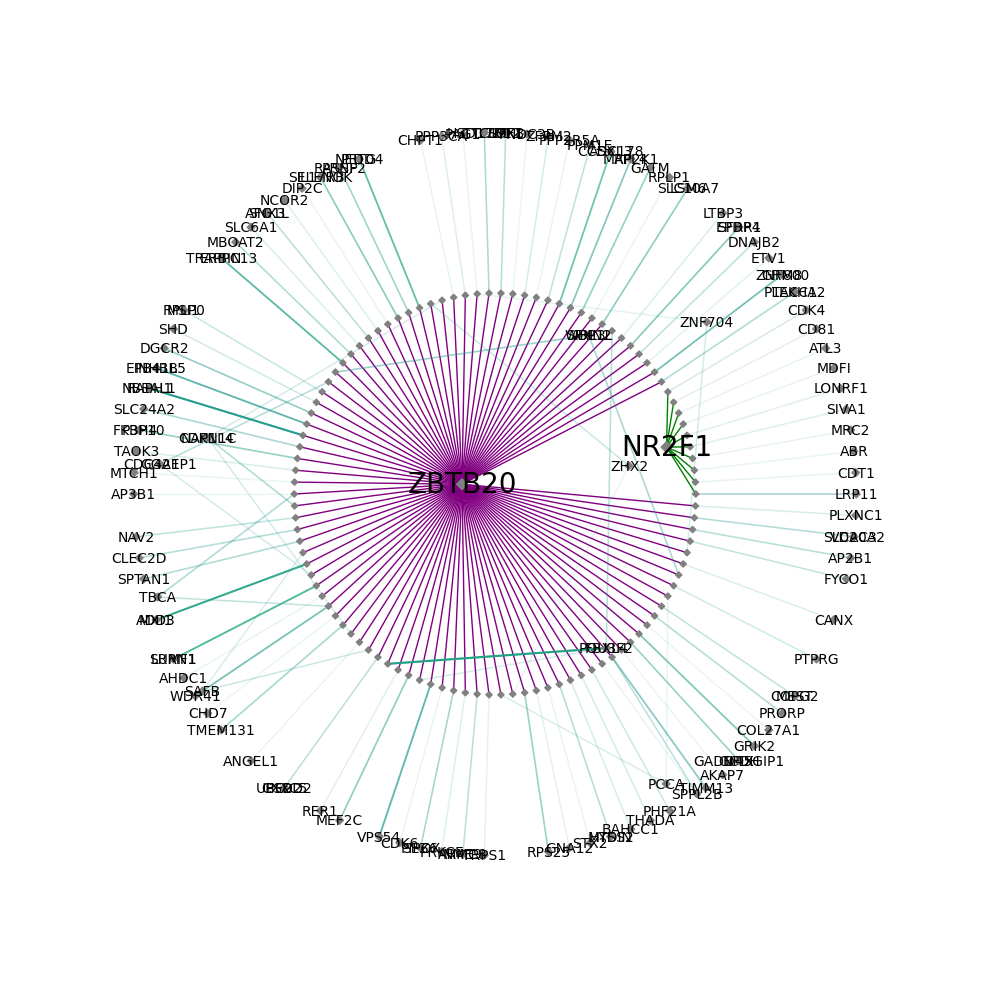

In [161]:
# To draw with networkx
plt.figure(figsize=(10,10))
plot_networkx(G_c, pos_c)

In [162]:
edge_tables_c = edge_tables_c.reset_index() #must reindex first!
del edge_tables_c['index']
# 为edge_tables_c添加link_type列，用于区分Region-Gene和TF-Region
edge_tables_c['link_type'] = ['R2G' if i==True else "TF2R" for i in edge_tables_c['source'].str.startswith('chr') ]

In [163]:
edge_tables_c

,source,target,color,width,color_rgb,color_alpha,link_type
0,ZBTB20,chr19:13022151-13022652,#800080ff,1,#800080,255.000000,TF2R
1,ZBTB20,chr10:102628252-102628753,#800080ff,1,#800080,255.000000,TF2R
2,ZBTB20,chr10:102815303-102815804,#800080ff,1,#800080,255.000000,TF2R
3,ZBTB20,chr10:102815303-102815804,#800080ff,1,#800080,255.000000,TF2R
4,ZBTB20,chr5:139764325-139764826,#800080ff,1,#800080,255.000000,TF2R
...,...,...,...,...,...,...,...
295,chr8:12658724-12659225,LONRF1,#23898e22,1.060432,#23898e,201.921397,R2G
296,chr11:2539630-2540131,CD81,#287d8e1e,1.053618,#287d8e,200.960699,R2G
297,chr6:149941671-149942172,LRP11,#24878e63,1.19001,#24878e,217.532751,R2G
298,chr6:41555404-41555905,MDFI,#23898e1b,1.047945,#23898e,200.240175,R2G


In [164]:
links = pd.Series([ "-".join(row)  for i , row in edge_tables_c.loc[:,['source','target']].iterrows()])

In [165]:
idx = links.duplicated() #显示出重复的edge，但会留第一个True,在画网络图的时候，需要一个TF只指向一个Region, 一个Region只指向一个Gene

In [166]:
idx.sum() #21
edge_tables_c[idx]['source'].str.startswith('chr').value_counts() 

False    44
Name: source, dtype: int64

In [167]:
edge_tables_c_filter = edge_tables_c[~idx] #去掉有重复的edge，只留下one-to-one的edge

In [168]:
edge_tables_c_filter

,source,target,color,width,color_rgb,color_alpha,link_type
0,ZBTB20,chr19:13022151-13022652,#800080ff,1,#800080,255.000000,TF2R
1,ZBTB20,chr10:102628252-102628753,#800080ff,1,#800080,255.000000,TF2R
2,ZBTB20,chr10:102815303-102815804,#800080ff,1,#800080,255.000000,TF2R
4,ZBTB20,chr5:139764325-139764826,#800080ff,1,#800080,255.000000,TF2R
12,ZBTB20,chr16:70760631-70761132,#800080ff,1,#800080,255.000000,TF2R
...,...,...,...,...,...,...,...
295,chr8:12658724-12659225,LONRF1,#23898e22,1.060432,#23898e,201.921397,R2G
296,chr11:2539630-2540131,CD81,#287d8e1e,1.053618,#287d8e,200.960699,R2G
297,chr6:149941671-149942172,LRP11,#24878e63,1.19001,#24878e,217.532751,R2G
298,chr6:41555404-41555905,MDFI,#23898e1b,1.047945,#23898e,200.240175,R2G


In [169]:
# 为了画图，需要一个Region只指向一个Gene
edge_tables_R2G = edge_tables_c_filter[edge_tables_c_filter['link_type'] == 'R2G']
edge_tables_R2G['source'].duplicated().sum() 
idx3 = edge_tables_R2G['source'].duplicated() 
edge_tables_R2G_filter = edge_tables_R2G[~idx3] 

In [170]:
idx3.sum()

44

In [171]:
# edge_tables_R2G_filter_top3 = edge_tables_R2G_filter.groupby('target').apply(lambda x: x.sort_values(by = 'width', ascending = False).head(3)).reset_index(drop = True)
#166 rows × 7 columns

In [172]:
edge_tables_TF2R = edge_tables_c_filter[edge_tables_c_filter['link_type'] == 'TF2R']

In [173]:
edge_tables_TF2R

,source,target,color,width,color_rgb,color_alpha,link_type
0,ZBTB20,chr19:13022151-13022652,#800080ff,1,#800080,255.0,TF2R
1,ZBTB20,chr10:102628252-102628753,#800080ff,1,#800080,255.0,TF2R
2,ZBTB20,chr10:102815303-102815804,#800080ff,1,#800080,255.0,TF2R
4,ZBTB20,chr5:139764325-139764826,#800080ff,1,#800080,255.0,TF2R
12,ZBTB20,chr16:70760631-70761132,#800080ff,1,#800080,255.0,TF2R
...,...,...,...,...,...,...,...
145,NR2F1,chr8:12658724-12659225,#008000ff,1,#008000,255.0,TF2R
146,NR2F1,chr11:2539630-2540131,#008000ff,1,#008000,255.0,TF2R
147,NR2F1,chr6:149941671-149942172,#008000ff,1,#008000,255.0,TF2R
148,NR2F1,chr6:41555404-41555905,#008000ff,1,#008000,255.0,TF2R


In [174]:
edge_tables_TF2R['target'].isin(edge_tables_R2G_filter['source']).sum() #132

106

In [175]:
idx4 = edge_tables_TF2R['target'].isin(edge_tables_R2G_filter['source']) # 要保证TF-Region的Region是能指向基因的。

In [176]:
edge_tables_TF2R_filter = edge_tables_TF2R[idx4]


In [461]:
edge_tables_R2G_filter[edge_tables_R2G_filter['source'].isin(['chr14:51989257-51989758'])]

,source,target,color,width,color_rgb,color_alpha,link_type
156,chr14:51989257-51989758,GNG2,#29798e1d,1.054934,#29798e,200.720524,R2G


In [177]:
edge_tables_filter = pd.concat([edge_tables_TF2R_filter,edge_tables_R2G_filter ],axis = 0).reset_index(drop = True)


In [178]:
edge_tables_filter

,source,target,color,width,color_rgb,color_alpha,link_type
0,ZBTB20,chr19:13022151-13022652,#800080ff,1,#800080,255.000000,TF2R
1,ZBTB20,chr10:102628252-102628753,#800080ff,1,#800080,255.000000,TF2R
2,ZBTB20,chr10:102815303-102815804,#800080ff,1,#800080,255.000000,TF2R
3,ZBTB20,chr5:139764325-139764826,#800080ff,1,#800080,255.000000,TF2R
4,ZBTB20,chr16:70760631-70761132,#800080ff,1,#800080,255.000000,TF2R
...,...,...,...,...,...,...,...
207,chr8:12658724-12659225,LONRF1,#23898e22,1.060432,#23898e,201.921397,R2G
208,chr11:2539630-2540131,CD81,#287d8e1e,1.053618,#287d8e,200.960699,R2G
209,chr6:149941671-149942172,LRP11,#24878e63,1.19001,#24878e,217.532751,R2G
210,chr6:41555404-41555905,MDFI,#23898e1b,1.047945,#23898e,200.240175,R2G


In [181]:
edge_tables_c.to_csv('./cytoscape/edge_tables_degree_dIPC_switched.txt',sep='\t',index=False)
edge_tables_filter.to_csv('./cytoscape/edge_tables_degree_filter_dIPC_switched.txt',sep='\t',index=False)
# edge_tables_filter_top3.to_csv('./cytoscape/edge_tables_filter_top3.txt',sep='\t',index=False)

In [182]:
node_tables_c

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
NR2F1,TF,NR2F1,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
ZBTB20,TF,ZBTB20,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
chr11:65558091-65558592,Region,chr11:65558091-65558592,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr6:149941671-149942172,Region,chr6:149941671-149942172,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr17:58756076-58756577,Region,chr17:58756076-58756577,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
...,...,...,...,...,...,...,...,...,...,...,...
EPDR1,Gene,EPDR1,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
RPLP0,Gene,RPLP0,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
FKBP10,Gene,FKBP10,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255


In [183]:
node_tables_TF = node_tables_c[node_tables_c['group'] == 'TF' ]
node_tables_Region = node_tables_c[node_tables_c['group'] == 'Region' ]
node_tables_Gene = node_tables_c[node_tables_c['group'] == 'Gene' ]


In [184]:
node_tables_TF

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
NR2F1,TF,NR2F1,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
ZBTB20,TF,ZBTB20,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255


In [185]:
node_tables_Region

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
chr11:65558091-65558592,Region,chr11:65558091-65558592,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr6:149941671-149942172,Region,chr6:149941671-149942172,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr17:58756076-58756577,Region,chr17:58756076-58756577,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr1:212452810-212453311,Region,chr1:212452810-212453311,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr5:77973157-77973658,Region,chr5:77973157-77973658,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
...,...,...,...,...,...,...,...,...,...,...,...
chr17:29089549-29090050,Region,chr17:29089549-29090050,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr17:81387273-81387774,Region,chr17:81387273-81387774,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr19:2475792-2476293,Region,chr19:2475792-2476293,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255


In [186]:
node_tables_Gene

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
POU3F2,Gene,POU3F2,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
HSD17B12,Gene,HSD17B12,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
SNX3,Gene,SNX3,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
THADA,Gene,THADA,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
PTPRG,Gene,PTPRG,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
...,...,...,...,...,...,...,...,...,...,...,...
EPDR1,Gene,EPDR1,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
RPLP0,Gene,RPLP0,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
FKBP10,Gene,FKBP10,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255


In [187]:
node_tables_TF['label'].duplicated().sum()#0
node_tables_Region['label'].duplicated().sum()#0
node_tables_Gene['label'].duplicated().sum()#0

0

In [188]:
node_tables_TF.index = node_tables_TF['label']
node_tables_Region.index = node_tables_Region['label']
node_tables_Gene.index = node_tables_Gene['label']

In [189]:
X_ACC = scplus_obj.X_ACC.copy() # 162500 rows × 10248 columns


In [190]:
X_EXP = scplus_obj.X_EXP.copy().T # 36601 rows × 10248 columns

In [191]:

metadata = scplus_obj.metadata_cell.copy()


In [192]:
metadata

,sample2,barcode2,celltype
CTGACCAAGCATGTTA-1-4___cisTopic,GW10,CTGACCAAGCATGTTA-1,ExN_naive
GGCCATCAGGGACCTC-1-6___cisTopic,GW17,GGCCATCAGGGACCTC-1,OPC
AATCGCCCAATTAGGA-1-2___cisTopic,GW7,AATCGCCCAATTAGGA-1,ExN_naive
AGGACGTAGGAAACTG-1-1___cisTopic,GW12,AGGACGTAGGAAACTG-1,OPC
CCAGGAACAATCCTAG-1-4___cisTopic,GW10,CCAGGAACAATCCTAG-1,ExN_naive
...,...,...,...
TCCTTAGTCGCTAGCA-1-5___cisTopic,GW16,TCCTTAGTCGCTAGCA-1,NPC
CCTGGATCACAAAGAC-1-5___cisTopic,GW16,CCTGGATCACAAAGAC-1,OPC
CTGTACCTCCGTGACA-1-7___cisTopic,GW20,CTGTACCTCCGTGACA-1,OPC
ATGAAGCCAGCTTAAT-1-1___cisTopic,GW12,ATGAAGCCAGCTTAAT-1,ExN_naive


In [193]:
(X_ACC.columns == X_EXP.columns).all()#True
(X_ACC.columns == metadata.index).all() #True

True

In [194]:
metadata['celltype'].value_counts()

OPC               3374
NPC               1846
ExN_naive         1789
dIPC              1400
dIPC_switched      946
InN_naive          731
dIPC_switching     162
Name: celltype, dtype: int64

In [195]:
##aggregate pseudobulk exprMat and accMat

def aggregate_X_simple(mat, metadata_df, method = 'sum'):

    celltype = list(metadata['celltype'].cat.categories)
    
    exprMat_ave = pd.DataFrame(index = mat.index,columns = celltype)
    
    for g in celltype:
        cellid = metadata_df[metadata_df['celltype'] == g].index
        size = len(cellid)

        if size >= 10:
            if method == "sum":
                mat_ave_sel = mat.loc[:,cellid].sum(axis = 1)
            elif method == "mean":
                mat_ave_sel = mat.loc[:,cellid].mean(axis = 1)
            else:
                print('wrong aggregate method ' + method)
                break
                
            exprMat_ave[g] = mat_ave_sel
        else:
            print('Error, group size < 10 at ' + g)


    if exprMat_ave.isna().sum().sum() != 0:
        print('NA found')

    return(exprMat_ave)

In [196]:
exprMat = aggregate_X_simple(mat = X_EXP.copy(), metadata_df = metadata.copy(), method = 'mean')       
#36601 rows × 6 columns

In [197]:
accMat = aggregate_X_simple(mat = X_ACC.copy(), metadata_df = metadata.copy(), method = 'mean')  
#162500 rows × 6 columns

In [198]:
de_markers_all = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/Neuron/neuron_marker_celltype_de.csv')

In [199]:
de_markers_all

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ExN_naive,CACNA2D1,59.377150,14.508904,0.000000,0.000000
1,ExN_naive,EBF1,58.252937,13.975989,0.000000,0.000000
2,ExN_naive,MYT1L,50.742653,6.133754,0.000000,0.000000
3,ExN_naive,EBF3,45.293060,5.353375,0.000000,0.000000
4,ExN_naive,RMST,44.272346,6.938861,0.000000,0.000000
...,...,...,...,...,...,...
7978,dIPC_switching,CRNDE,3.843473,1.117068,0.000121,0.008425
7979,dIPC_switching,NCK2,3.817132,1.322697,0.000135,0.009289
7980,dIPC_switching,CORO1C,3.816222,1.020861,0.000136,0.009305
7981,dIPC_switching,MTMR2,3.809329,1.303802,0.000139,0.009551


In [200]:
de_markers_all['group'].value_counts()

NPC               4015
OPC               1195
ExN_naive         1148
InN_naive          614
dIPC               409
dIPC_switched      381
dIPC_switching     221
Name: group, dtype: int64

In [201]:
cell_type_dict = {
        'NPC' : 'NPC',  
        'dIPC' : 'dIPC', 
        'ExN_naive' : 'ExN_naive',
        'InN_naive' : 'InN_naive',
        'dIPC_switching' : 'dIPC_switching',
        'dIPC_switched' : 'dIPC_switched',
        'OPC' : 'OPC'
}

In [202]:
(pd.Series(de_markers_all['group'].value_counts().index).isin(cell_type_dict.keys())).all()#True


True

In [203]:
de_markers_all_new = de_markers_all.copy()


In [204]:

de_markers_all_new['group'] = de_markers_all_new['group'].map(cell_type_dict)


In [205]:

de_markers_all_new['group'] = de_markers_all_new['group'].astype('category').cat.set_categories(
    ['NPC', 'dIPC','ExN_naive', 'InN_naive', 'dIPC_switching', 'dIPC_switched', 'OPC'])


In [206]:
de_markers_all_new['group']

0            ExN_naive
1            ExN_naive
2            ExN_naive
3            ExN_naive
4            ExN_naive
             ...      
7978    dIPC_switching
7979    dIPC_switching
7980    dIPC_switching
7981    dIPC_switching
7982    dIPC_switching
Name: group, Length: 7983, dtype: category
Categories (7, object): ['NPC', 'dIPC', 'ExN_naive', 'InN_naive', 'dIPC_switching', 'dIPC_switched', 'OPC']

In [207]:
de_markers_all_new['group'].value_counts().sort_index()

NPC               4015
dIPC               409
ExN_naive         1148
InN_naive          614
dIPC_switching     221
dIPC_switched      381
OPC               1195
Name: group, dtype: int64

In [208]:
(de_markers_all.index == de_markers_all_new.index).all() #True


True

In [209]:
bed_files_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/pycisTopic/Neuron/cistopic_data/region_sets/DARs_cell_type"
bed_files = glob.glob(os.path.join(bed_files_path, "*.bed"))

all_data = []
for bed_file in bed_files:
    celltype = os.path.basename(bed_file).replace('.bed', '')
    df_temp = pd.read_csv(bed_file, sep='\t', header=None)
    if df_temp.shape[1] >= 3:
        # chr, start, end
        df_temp = df_temp.iloc[:, :3]
        df_temp.columns = ['chr', 'start', 'end']
        # chr:start-end
        df_temp['peakid'] = df_temp['chr'] + ':' + df_temp['start'].astype(str) + '-' + df_temp['end'].astype(str)
        df_temp['celltype'] = celltype
        all_data.append(df_temp)


In [210]:
dar_table = pd.concat(all_data, ignore_index=True)

In [211]:
dar_table['celltype'] = dar_table['celltype'].astype('category').cat.set_categories(
    ['NPC', 'dIPC','ExN_naive', 'InN_naive', 'dIPC_switching', 'dIPC_switched', 'OPC'])


In [212]:
dar_table['celltype'].value_counts().sort_index()

NPC               12624
dIPC              10936
ExN_naive         13410
InN_naive         13966
dIPC_switching    10933
dIPC_switched     12219
OPC               11027
Name: celltype, dtype: int64

In [214]:
cid = 'dIPC_switched'

In [215]:
(node_tables_TF['label'].isin(exprMat.index)).all() #True
(pd.Series(cid).isin(exprMat.columns)).all() #True
node_tables_TF['expr.value'] = exprMat.loc[node_tables_TF['label'],cid]

In [216]:
(node_tables_Gene['label'].isin(exprMat.index)).all() #True
(pd.Series(cid).isin(exprMat.columns)).all() #True
node_tables_Gene['expr.value'] = exprMat.loc[node_tables_Gene['label'],cid]

In [217]:
(node_tables_Region['label'].isin(accMat.index)).all() #True
(pd.Series(cid).isin(accMat.columns)).all() #True
node_tables_Region['acc_value'] = accMat.loc[node_tables_Region['label'],cid]

In [218]:
(pd.Series(cid).isin(de_markers_all_new['group'])).all() #True
flag = node_tables_TF['label'].isin(de_markers_all_new[de_markers_all_new['group'] == cid]['names'])
node_tables_TF['deg_label'] = node_tables_TF['label'][flag]
flag = node_tables_Gene['label'].isin(de_markers_all_new[de_markers_all_new['group'] == cid]['names'])
node_tables_Gene['deg_label'] = node_tables_Gene['label'][flag]
pos = np.where(de_markers_all_new[de_markers_all_new['group'] == cid]['names'].isin(node_tables_Gene['label']) )
node_tables_Gene['deg_label'].isna().sum() #61
node_tables_Gene['isDEG'] = ['No' if i == True else "Yes" for i in node_tables_Gene['deg_label'].isna()]


In [219]:
(pd.Series(cid).isin(dar_table['celltype'])).all() #True
flag = node_tables_Region['label'].isin(dar_table[dar_table['celltype'] == cid]['peakid']) #127

In [220]:
node_tables_Region['dar_label'] = node_tables_Region['label'][flag]#'"'+node_tables_Region['label'][flag]+'"'
node_tables_Region['dar_label'].isna().sum() #103
node_tables_Region['isDAR'] = ['No' if i == True else "Yes" for i in node_tables_Region['dar_label'].isna()]

In [221]:
node_tables_c_filter = pd.concat([node_tables_TF,node_tables_Gene,node_tables_Region],axis = 0,)
node_tables_c_filter['celltype'] = 'dIPC_switched'
node_tables_c_filter = node_tables_c_filter.reset_index(drop=True)
node_tables_c_filter['label'].duplicated().sum()#0

0

In [222]:
#write node table
node_tables_c.to_csv('./cytoscape/node_tables_degree_dIPC_switched.txt',sep='\t',index=False)
node_tables_c_filter.to_csv('./cytoscape/node_tables_degree_filter_dIPC_switched.txt',sep='\t',index=False,na_rep = ' ')

In [ ]:
# export_to_cytoscape(G_c, pos_c,
#                     './cytoscape/OLIG2_SOX5_SOX6_TCF4.network.cyjs',
#                     pos_scaling_factor=200, size_scaling_factor=1)